In [1]:
import numpy as np
from matplotlib import pyplot as plt
from netCDF4 import Dataset
import datetime as dt
import scipy.io as sio
from mpl_toolkits.basemap import Basemap
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import pearsonr
from matplotlib import cm
import h5py
import glob
# import cmasher as cmr
import cmcrameri as cram

In [2]:
product= 'S1'

In [3]:
if product == 'S1':
    dateini = dt.datetime(2018,1,1)


In [4]:
dateini

datetime.datetime(2018, 1, 1, 0, 0)

In [5]:
filename = glob.glob('IWU*.hdf5')

In [6]:
filename[0]

IndexError: list index out of range

In [99]:
data = h5py.File(filename[0],'r')
irr = data['IRR'][:,:,:]
lats = data['lat'][:,:]
lons = data['lon'][:,:]
data.close()

In [100]:
print (irr.shape)

(2557, 134, 168)


In [101]:
datex= [dateini+ dt.timedelta(days=i) for i in range(irr.shape[0])]

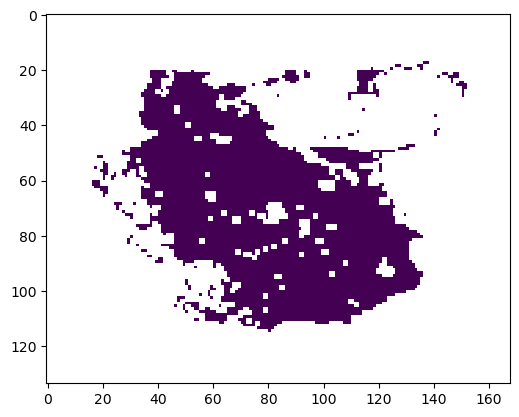

In [102]:
MASK = np.loadtxt('MASK_Foggia_AGR.txt')
plt.imshow(MASK)

In [103]:
IRR = irr * MASK

C:\Users\Jacopo\AppData\Local\Temp\ipykernel_9884\716192989.py:1: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(IRR,axis=0))


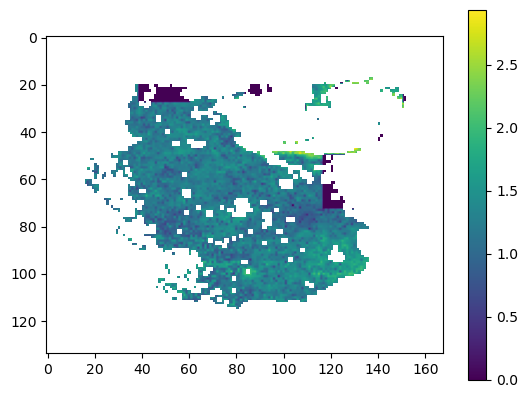

In [104]:
plt.imshow(np.nanmean(IRR,axis=0))
plt.colorbar()

In [105]:
IRRn_flat = np.empty((IRR.shape[0], IRR.shape[1]*IRR.shape[2]))
for i in range(IRR.shape[0]):
    IRRn_flat[i,:] = IRR[i,:,:].reshape(IRR.shape[1]*IRR.shape[2])

In [106]:
#dataframe
IRRn_dataframe = pd.DataFrame(IRRn_flat, index = datex)
IRRn_dataframe[(IRRn_dataframe.index.month < 5) | (IRRn_dataframe.index.month > 9) ] = 0

IRRn_dataframe_M = IRRn_dataframe.resample('M', convention='start').sum()

IRRn_dataframe_Y = IRRn_dataframe.resample('Y', convention='start').sum()



In [107]:
IRRn_dataframe_M

,0,1,2,3,4,5,6,7,8,9,...,22502,22503,22504,22505,22506,22507,22508,22509,22510,22511
2018-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-02-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-03-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-05-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-09-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-10-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-11-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
IRRn_dataframe_M.max

<bound method NDFrame._add_numeric_operations.<locals>.max of             0      1      2      3      4      5      6      7      8      \
2018-01-31    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2018-02-28    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2018-03-31    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2018-04-30    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2018-05-31    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
...           ...    ...    ...    ...    ...    ...    ...    ...    ...   
2024-08-31    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2024-09-30    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2024-10-31    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2024-11-30    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2024-12-31    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   

            9

<AxesSubplot:>

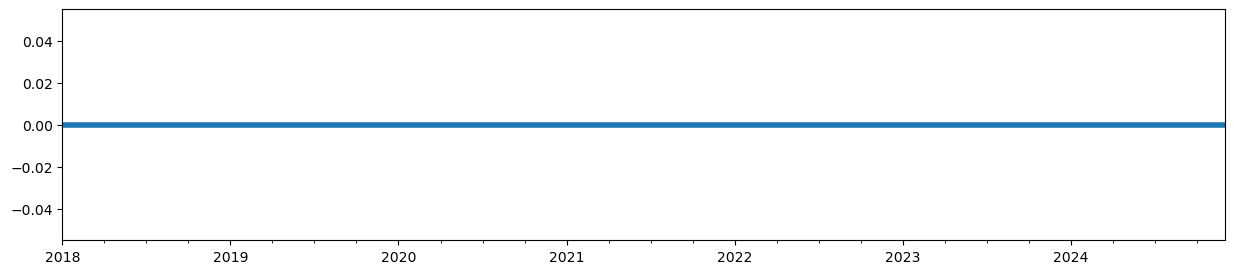

In [109]:
fig=plt.figure(figsize=(15,3))
IRRn_dataframe_M[6400].plot(linewidth=4) #original

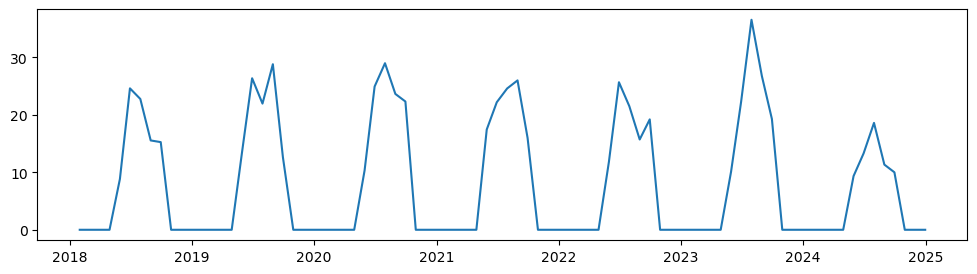

In [110]:
IRRn_dataframe_Marray = np.asarray(IRRn_dataframe_M)
fig = plt.figure(figsize=(12,3))
plt.plot(IRRn_dataframe_M.index[:], np.nanmean(IRRn_dataframe_Marray,axis=1)[:])

In [111]:
IRRn_dataframe_Yarray = np.asarray(IRRn_dataframe_Y)


In [112]:
aggirr = np.empty((IRRn_dataframe_Yarray.shape[0],IRR.shape[1], IRR.shape[2]))
for i in range(aggirr.shape[0]):
    aggirr[i,:,:] = IRRn_dataframe_Yarray[i,:].reshape(IRR.shape[1], IRR.shape[2])

In [113]:
aggirr.shape

(7, 134, 168)

In [114]:
M = np.nanmean(aggirr,axis=0)

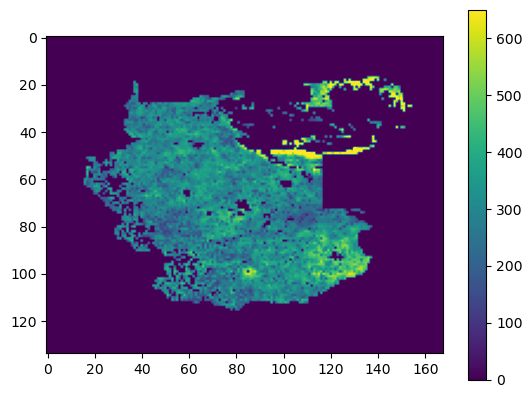

In [115]:
plt.imshow(M,vmax=650)
plt.colorbar()

In [116]:
seasonalmean = M * MASK

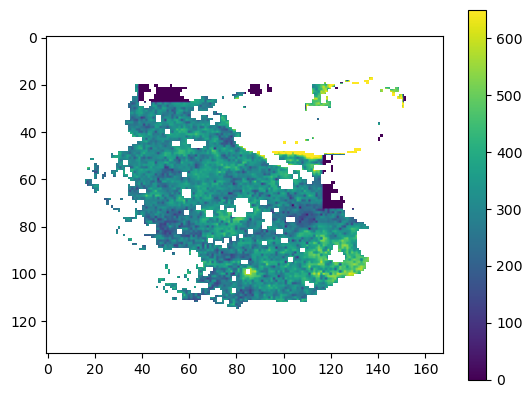

In [117]:
plt.imshow(seasonalmean,vmax=650)
plt.colorbar()

In [118]:
AA = lons.min()
BB = lons.max()
CC = lats.min()
DD = lats.max()


In [119]:
def plotMapsum(lats,lons,values,units,title,colormap):

    plt.title(title, fontsize=22)
    m = Basemap(llcrnrlon=AA-0.05,
                    llcrnrlat=CC-0.05,urcrnrlon=BB+0.05,
                    urcrnrlat=DD+0.05, epsg = 4326)
    #m.readshapefile('D:\Elab\CHEBRO_J\MERGED_IRR_RECOVERED_dissolto84','MERGED_IRR_RECOVERED_dissolto84',linewidth = 0.5, color ='w')



    m.arcgisimage(service='World_Shaded_Relief', xpixels = 2000, verbose= False)#ESRI_Imagery_World_2D #Elevation/World_Hillshade_Dark
    #m.drawlsmask(ocean_color='royalblue',alpha = 0.8,lakes=True)
    parallels = np.arange(-90,120,0.5)
    par = m.drawparallels(parallels,labels=[False,True,True,False], fontsize = 20)
    meridians = np.arange(-180,180,0.5)
    mer = m.drawmeridians(meridians,labels=[True,False,False,True],fontsize = 20)
    m.readshapefile('C:\Projects/IrrigationEU/Puglia_exp/CLC_18_Foggia','CLC_18_Foggia',color ='k', linewidth = 0.6)
    m.readshapefile('D:\Elab\ITAshp\gadm36_ITA_0','gadm36_ITA_0',color ='k', linewidth = 1)

    
    #setcolor(par,'w')
    #setcolor(mer,'w')

    #(X,Y) = m(lons,lats)
    cs=plt.pcolor(lons,lats,values,vmin=100,vmax=600,cmap=cram.cm.lapaz_r)

    cbar = m.colorbar(cs,location='bottom',extend = 'both',pad='7%')
    cbar.set_label(units, fontsize = 18)
    cbar.ax.tick_params(labelsize=18)

{'whiskers': [<matplotlib.lines.Line2D at 0x22ec9bed130>,
 'caps': [<matplotlib.lines.Line2D at 0x22ec9bed6d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x22ec9be0f40>],
 'medians': [<matplotlib.lines.Line2D at 0x22ec9bedc70>],
 'fliers': [<matplotlib.lines.Line2D at 0x22ec9bedf40>],
 'means': []}

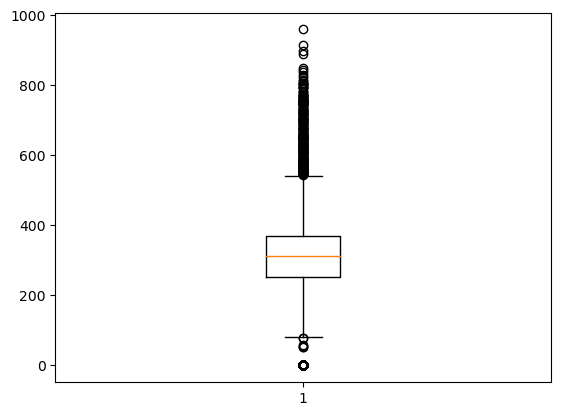

In [120]:
plt.boxplot(seasonalmean[np.isfinite(seasonalmean)])

C:\Users\Jacopo\Anaconda3\envs\ESALTC22_JD\lib\site-packages\pyproj\crs\crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


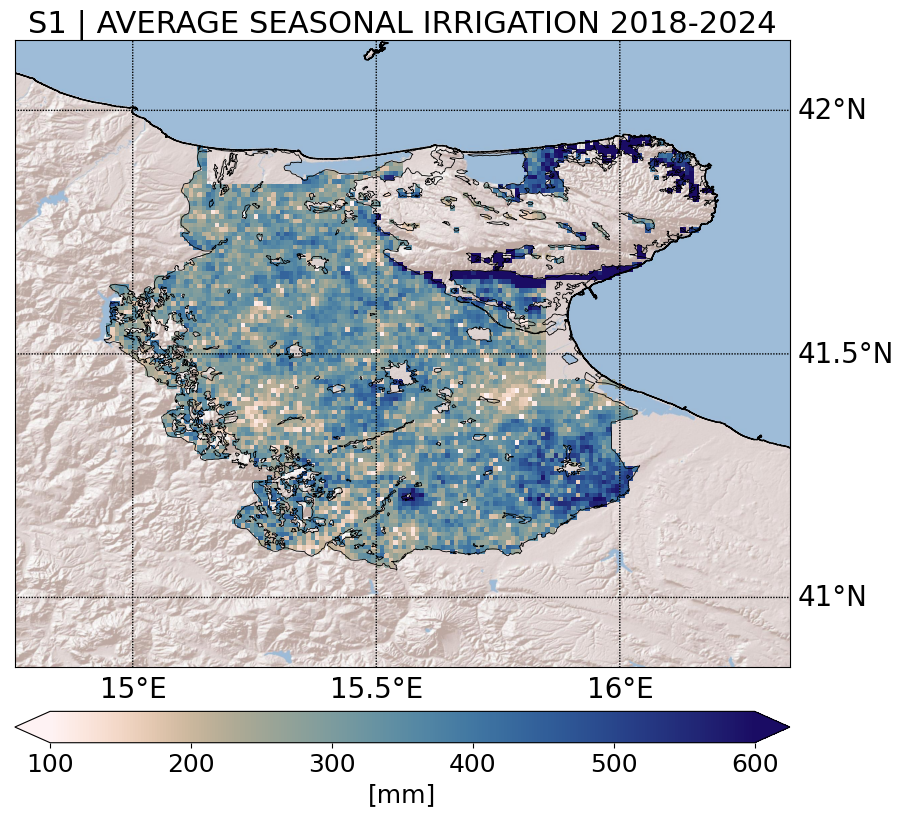

In [121]:
seasonalmean[seasonalmean==0]=np.nan
fig = plt.figure(figsize=(10,10))
plotMapsum(lats,lons,seasonalmean,'[mm]', 'S1 | AVERAGE SEASONAL IRRIGATION 2018-2024',plt.cm.Blues)
plt.show()

fig.savefig('PP_MAP_'+product+'.png',pad_inches =0.1,bbox_inches = 'tight')

C:\Users\Jacopo\AppData\Local\Temp\ipykernel_9884\1924663264.py:7: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  ax.grid(b=1, which ='both',axis='both',linestyle = '--', linewidth = 0.5)


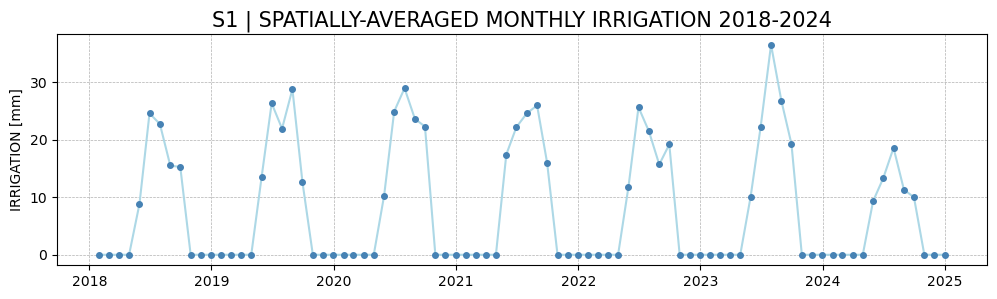

In [122]:
fig = plt.figure(figsize=(12,3))
plt.title('S1 | SPATIALLY-AVERAGED MONTHLY IRRIGATION 2018-2024',fontsize=15)
plt.ylabel('IRRIGATION [mm]')
plt.plot(IRRn_dataframe_M.index[:], np.nanmean(IRRn_dataframe_Marray,axis=1)[:],'-',c='lightblue')
plt.plot(IRRn_dataframe_M.index[:], np.nanmean(IRRn_dataframe_Marray,axis=1)[:],'o',markersize=4,c='steelblue')
ax=plt.gca()
ax.grid(b=1, which ='both',axis='both',linestyle = '--', linewidth = 0.5)

fig.savefig('PP_TS_'+product+'.png',pad_inches =0.1,bbox_inches = 'tight')